# NYC Crime Data Machine Learning & Crime Forecasting
The purpose of this notebook is to use predictive models to forecast crime rates and locations by using the patterns identified in the EDA.

In [9]:
#Library imports
import pandas as pd
import numpy as np
import holidays

In [10]:
#load and filter data for only Brooklyn
df = pd.read_csv('nyc_crime_data_cleaned.csv')
bk_df = df[df['BORO_NM'] == 'BROOKLYN'].copy()
bk_df['CMPLNT_FR_DTTM'] = pd.to_datetime(bk_df['CMPLNT_FR_DTTM'])
bk_df['date'] = bk_df['CMPLNT_FR_DTTM'].dt.date
print(f"Total Brooklyn crimes: {len(bk_df)}")

Total Brooklyn crimes: 14791


C:\Users\Nicol\AppData\Local\Temp\ipykernel_19308\2963090608.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('nyc_crime_data_cleaned.csv')


## Time Series Data Formatting
Formatting the data by identifying a proper time unit of analysis and creating a target variable

In [11]:
#Create 4-hour time windows/shifts where the bins are as follows: 0-4, 4-8, 8-12, 12-16, 16-20, 20-24
bk_df['hour'] = bk_df['CMPLNT_FR_DTTM'].dt.hour
bk_df['shift_window'] = (bk_df['hour']//4)*4 

#Count crimes per precinct per shift (target variable 'y' which is incident count)
crime_counts = bk_df.groupby(['date', 'shift_window', 'ADDR_PCT_CD']).size().reset_index(name='incident_count')

#Create the overall time grid for ML dataset which ensures there are rows for every date, shift, and precinct combination
all_dates = pd.date_range(start=bk_df['date'].min(), end=bk_df['date'].max()).date
all_shifts = [0, 4, 8, 12, 16, 20]
all_precincts = bk_df['ADDR_PCT_CD'].unique()

#Create a multiIndex for the full grid and convert to a dataframe
index = pd.MultiIndex.from_product([all_dates, all_shifts, all_precincts], names=['date', 'shift_window', 'ADDR_PCT_CD'])
master_grid = pd.DataFrame(index=index).reset_index()

#Merge crimes into the overall time grid
ml_data = pd.merge(master_grid, crime_counts, on=['date', 'shift_window', 'ADDR_PCT_CD'], how='left')

#Fill null counts with 0 since no crimes were reported in these windows
ml_data['incident_count'] = ml_data['incident_count'].fillna(0).astype(int)

#Preview the structured data
print(f"Total rows for ML: {len(ml_data)}")
print(ml_data.head())

Total rows for ML: 113880
         date  shift_window  ADDR_PCT_CD  incident_count
0  2017-01-02             0           75               0
1  2017-01-02             0           70               0
2  2017-01-02             0           66               0
3  2017-01-02             0           83               1
4  2017-01-02             0           62               0


## Feature Engineering
Incorporating cyclical time encoding, lag features, binary flags, and spatial interactions to incorporate seasonality trends into the data since time of the year does affect crime rates

##### Cyclical Time Encoding and Binary Flags

In [12]:
#Convert to datetime for feature engineering
ml_data['date'] = pd.to_datetime(ml_data['date'])

#Cyclical time (shift window) 
ml_data['shift_sin'] = np.sin(2 * np.pi * ml_data['shift_window'] / 24)
ml_data['shift_cos'] = np.cos(2 * np.pi * ml_data['shift_window'] / 24)

#Setup holidays
us_holidays = holidays.US(years=[2017, 2018, 2019])

#For each date, check if it's a holiday and create a binary feature
ml_data['is_holiday'] = ml_data['date'].dt.date.apply(lambda x: x in us_holidays).astype(int)

#Create other time-based features
ml_data['day_of_week'] = ml_data['date'].dt.dayofweek
ml_data['is_weekend'] = ml_data['day_of_week'].isin([5, 6]).astype(int)
ml_data['month'] = ml_data['date'].dt.month

##### Temporal Lag Features
These lag features allow the model to see the "short-term history" of a precinct.

In [13]:
#sort by precinct and time to ensure lags are chronological
ml_data = ml_data.sort_values(['ADDR_PCT_CD', 'date', 'shift_window'])

#lag feature 1: crime count is in the previous 4-hour window
ml_data['lag_4h'] = ml_data.groupby('ADDR_PCT_CD')['incident_count'].shift(1)

#lag feature 2: crime count is exactly 24 hours ago
ml_data['lag_24h'] = ml_data.groupby('ADDR_PCT_CD')['incident_count'].shift(6)

#lag feature 3: exact same shift 7 days ago
ml_data['lag_7d'] = ml_data.groupby('ADDR_PCT_CD')['incident_count'].shift(42)

#first rows of each precinct won't have lags
ml_data = ml_data.fillna(0)

#Calculate rolling statistics
ml_data = ml_data.sort_values(['ADDR_PCT_CD', 'date', 'shift_window'])

#7 day rolling average
ml_data['rolling_mean_7d'] = ml_data.groupby('ADDR_PCT_CD')['incident_count'].transform(
    lambda x: x.shift(1).rolling(window=42, min_periods=1).mean()
)

ml_data['rolling_std_7d'] = ml_data.groupby('ADDR_PCT_CD')['incident_count'].transform(
    lambda x: x.shift(1).rolling(window=42, min_periods=1).std()
)

ml_data[['rolling_mean_7d', 'rolling_std_7d']] = ml_data[['rolling_mean_7d', 'rolling_std_7d']].fillna(0)

##### Spatial Interaction
This identifies a precinct's patterns of behaviour in crime reports (e.g., street-heavy vs. residential-heavy crimes), allowing the model to understand that different environments react differently to the same event.

In [14]:
#Street and housing density features
precinct_profile = df.groupby('ADDR_PCT_CD')['PREM_TYP_DESC'].value_counts(normalize=True).unstack(fill_value=0)
precinct_profile['is_street_heavy'] = (precinct_profile['STREET'] > precinct_profile['STREET'].median()).astype(int)
precinct_profile['is_housing_heavy'] = (precinct_profile['RESIDENCE - PUBLIC HOUSING'] > precinct_profile['RESIDENCE - PUBLIC HOUSING'].median()).astype(int)

#Victim demographics features
vic_age_dist = df.groupby('ADDR_PCT_CD')['VIC_AGE_GROUP'].value_counts(normalize=True).unstack(fill_value=0)
vic_sex_dist = df.groupby('ADDR_PCT_CD')['VIC_SEX'].value_counts(normalize=True).unstack(fill_value=0)

precinct_profile['is_high_youth_vic'] = (vic_age_dist['<18'] > vic_age_dist['<18'].median()).astype(int)
precinct_profile['is_high_senior_vic'] = (vic_age_dist['65+'] > vic_age_dist['65+'].median()).astype(int)
precinct_profile['is_high_female_vic'] = (vic_sex_dist['F'] > vic_sex_dist['F'].median()).astype(int)

#Commercial zone feature
retail_types = ['CHAIN STORE', 'DEPARTMENT STORE', 'GROCERY/BODEGA']
df['is_retail'] = df['PREM_TYP_DESC'].isin(retail_types)
comm_data = df.groupby('ADDR_PCT_CD')['is_retail'].mean()
precinct_profile['is_commercial_zone'] = (comm_data > comm_data.median()).astype(int)

#Merge all precinct-level features into the ML dataset
ml_data = ml_data.merge(
    precinct_profile[[
        'is_street_heavy', 'is_housing_heavy', 'is_commercial_zone', 
        'is_high_youth_vic', 'is_high_senior_vic', 'is_high_female_vic'
    ]], 
    on='ADDR_PCT_CD', 
    how='left'
).fillna(0)

## Model Selection
Test and evaluate different ML models with the data to see which one is best at predicting crime occurences.

##### Baseline Model: Poisson Regression
The standard model for modeling the probability of a certain number of events occurring in a fixed interval of time/space

In [15]:
#Import libraries for modeling
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import PoissonRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score

In [16]:
#Defining features and target

#Sort by date and shift to ensure proper time order for train-test split
ml_data = ml_data.sort_values(['date', 'shift_window', 'ADDR_PCT_CD'])

split_idx = int(len(ml_data) * 0.8)
train_df = ml_data.iloc[:split_idx]
test_df = ml_data.iloc[split_idx:]

#target is the crime count in the 4-hour window for each precinct
y = ml_data['incident_count']

#features for the model
features = [
    'shift_sin', 'shift_cos', 'month', 'day_of_week', 'is_weekend',
    'is_holiday', 'lag_4h', 'lag_24h', 'rolling_mean_7d', 'rolling_std_7d', 'lag_7d',
    'is_street_heavy', 'is_housing_heavy', 'is_commercial_zone',
    'is_high_youth_vic', 'is_high_senior_vic', 'is_high_female_vic'
]

X = ml_data[features]

#Time-series data split to preserve the time behaviour for training and testing

split_idx = int(len(ml_data) * 0.8) #80% for training, 20% for testing (future data)

X_train, y_train = train_df[features], train_df['incident_count']
X_test, y_test = test_df[features], test_df['incident_count']

print(f"Training on: {len(X_train)} rows")
print(f"Testing on: {len(X_test)} rows (Future data)")

#Train the baseline model

#scale data then use Poisson regression
poisson_model = make_pipeline(StandardScaler(), PoissonRegressor())
tscv = TimeSeriesSplit(n_splits=5)

poisson_cv_mae = -cross_val_score(poisson_model, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error').mean()

#train model
poisson_model.fit(X_train, y_train)

#make predictions on the test set
y_pred_poisson = poisson_model.predict(X_test)

#Evaluate baseline performance
mae = mean_absolute_error(y_test, y_pred_poisson)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_poisson))

print(f"Poisson Baseline MAE: {mae:.4f}")
print(f"Poisson Baseline RMSE: {rmse:.4f}")
print(f"Poisson Average CV MAE: {poisson_cv_mae:.4f}")

Training on: 91104 rows
Testing on: 22776 rows (Future data)
Poisson Baseline MAE: 0.2283
Poisson Baseline RMSE: 0.3680
Poisson Average CV MAE: 0.2268


##### Non-Linear Candidate: LightGBM
This model is good at finding complex interactions between location and time

In [17]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

#Initialize LightGBM
lgbm_model = lgb.LGBMRegressor(
    objective='poisson',
    n_estimators=1000,     
    learning_rate=0.05,    
    importance_type='gain',
    min_child_samples=5,
    bagging_fraction=0.8, #Use 80% of data for each iteration to reduce overfitting
    random_state=42
)

lgbm_cv_mae = -cross_val_score(lgbm_model, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error').mean()

#Fit the model
lgbm_model.fit(
    X_train, 
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=50)] #Stopping if no improvement in MAE for 50 rounds
)

#Make predictions
y_pred_lgbm = lgbm_model.predict(X_test)

#Evaluate performance
lgbm_mae = mean_absolute_error(y_test, y_pred_lgbm)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))

print(f"LightGBM MAE: {lgbm_mae:.4f}")
print(f"LightGBM RMSE: {lgbm_rmse:.4f}")
print(f"LightGBM Average CV MAE: {lgbm_cv_mae:.4f}")

[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001222 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 374
[LightGBM] [Info] Number of data points in the train set: 15184, number of used features: 17
[LightGBM] [Info] Start training from score -2.123055
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM

<Figure size 1000x600 with 0 Axes>

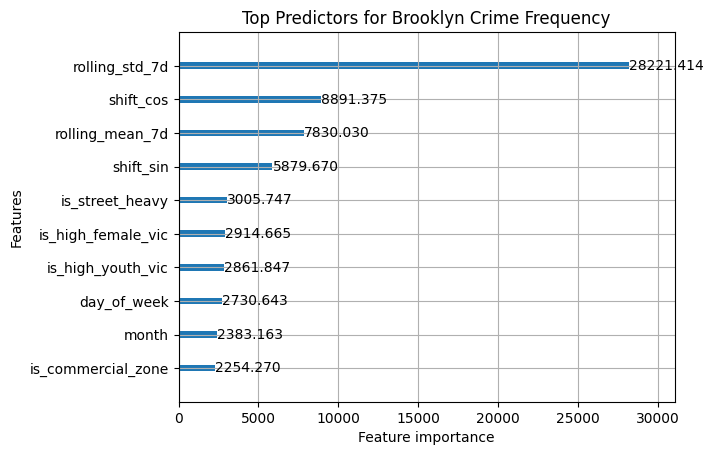

In [18]:
import matplotlib.pyplot as plt

#LightGBM feature importance visual
plt.figure(figsize=(10, 6))
lgb.plot_importance(lgbm_model, max_num_features=10, importance_type='gain')
plt.title("Top Predictors for Brooklyn Crime Frequency")
plt.show()

##### Linear Candidate: Lasso Regression
This model performs automatic feature selection and signal which ones are truly significant

In [19]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [20]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

#Use TimeSeriesSplit since this is time series data
tscv = TimeSeriesSplit(n_splits=5)

#LassoCV to search across 50 alphas
lasso_model = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=np.logspace(-4, 1, 50), cv=tscv, random_state=42)
)

lasso_model.fit(X_train, y_train)

#See what alpha it chose
best_alpha = lasso_model.named_steps['lassocv'].alpha_
print(f"Best alpha: {best_alpha:.6f}")

#Predictions and evaluation
y_pred_lasso = lasso_model.predict(X_test)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print(f"Lasso MAE: {lasso_mae:.4f}")
print(f"Lasso RMSE: {lasso_rmse:.4f}")

#Calculate average CV MAE across all folds for the best alpha
lasso_cv_mae = np.sqrt(np.min(lasso_model.named_steps['lassocv'].mse_path_.mean(axis=1)))
print(f"Lasso Average CV MAE: {lasso_cv_mae:.4f}")

Best alpha: 0.001326
Lasso MAE: 0.2232
Lasso RMSE: 0.3636
Lasso Average CV MAE: 0.3697


In [21]:
#See the feature importance breakdown determined by lasso coefficients
coefficients = lasso_model.named_steps['lassocv'].coef_
feature_importance = pd.Series(coefficients, index=features).sort_values(ascending=False)
print("Lasso Coefficients")
print(feature_importance)

Lasso Coefficients
rolling_std_7d        0.034793
rolling_mean_7d       0.016886
is_street_heavy       0.013548
is_commercial_zone    0.008730
is_high_female_vic    0.008326
is_high_youth_vic     0.007815
is_housing_heavy      0.004961
lag_7d                0.003142
month                 0.000407
lag_4h                0.000373
lag_24h               0.000000
day_of_week           0.000000
is_holiday            0.000000
is_weekend           -0.001609
is_high_senior_vic   -0.003481
shift_cos            -0.024989
shift_sin            -0.028412
dtype: float64


## Model Selection
Determine which model of the 3 to move forward with for hypertuning and final predictions

##### Performance Comparison

In [22]:
from sklearn.linear_model import Lasso, PoissonRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import pandas as pd
import numpy as np

#Poisson Regression
poisson_model = make_pipeline(StandardScaler(), PoissonRegressor())
poisson_model.fit(X_train, y_train)
y_pred_poisson = poisson_model.predict(X_test)

#Lasso Regression
lasso_model = make_pipeline(StandardScaler(), Lasso(alpha=0.1, random_state=42))
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

#LightGBM
lgbm_model = lgb.LGBMRegressor(objective='poisson', n_estimators=500, learning_rate=0.05, random_state=42)
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)] # Keeps output clean
)
y_pred_lgbm = lgbm_model.predict(X_test)

#Compile results
results = pd.DataFrame({
    'Model': ['Poisson (Baseline)', 'Lasso (Linear)', 'LightGBM (Non-Linear)'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_poisson),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_lgbm)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_poisson)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
    ]
}).sort_values(by='MAE')

print("Model Performance Comparison")
print(results)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 435
[LightGBM] [Info] Number of data points in the train set: 91104, number of used features: 17
[LightGBM] [Info] Start training from score -2.043902
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[258]	valid_0's l1: 0.220024	valid_0's poisson: 0.368066
Model Performance Comparison
                   Model       MAE      RMSE
2  LightGBM (Non-Linear)  0.220024  0.361442
0     Poisson (Baseline)  0.228260  0.367982
1         Lasso (Linear)  0.229749  0.370726


##### Residual Analysis

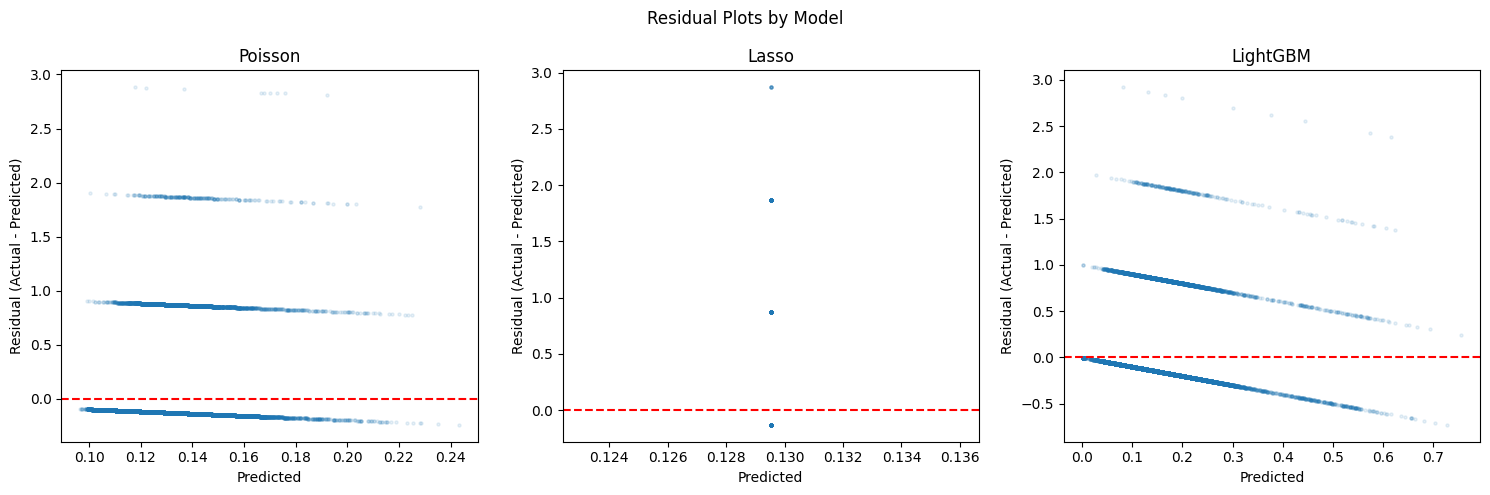

Average residual by shift window (LightGBM):
shift_sin
-8.660254e-01   -0.010494
-8.660254e-01   -0.007942
 0.000000e+00    0.009228
 1.224647e-16   -0.003684
 8.660254e-01   -0.006016
 8.660254e-01    0.007498
Name: residual, dtype: float64

Average residual on weekends vs weekdays:
is_weekend
0   -0.001584
1   -0.002689
Name: residual, dtype: float64


In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#Residual plots for each model to check for patterns in errors
models = {
    'Poisson': y_pred_poisson,
    'Lasso': y_pred_lasso,
    'LightGBM': y_pred_lgbm
}

for ax, (name, preds) in zip(axes, models.items()):
    residuals = y_test - preds
    ax.scatter(preds, residuals, alpha=0.1, s=5)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual (Actual - Predicted)')
    ax.set_title(name)

plt.suptitle('Residual Plots by Model')
plt.tight_layout()
plt.show()

#Also check if models under-predict during high-crime windows
test_df_eval = X_test.copy()
test_df_eval['actual'] = y_test.values
test_df_eval['pred_lgbm'] = y_pred_lgbm
test_df_eval['residual'] = test_df_eval['actual'] - test_df_eval['pred_lgbm']

print("Average residual by shift window (LightGBM):")
print(test_df_eval.groupby('shift_sin')['residual'].mean()) 

print("\nAverage residual on weekends vs weekdays:")
print(test_df_eval.groupby('is_weekend')['residual'].mean())

## Top Model Selection: LightGBM
LightGBM has the lowest MAE and RMSE out of the 3 models above and in the residual plot, its points are slightly tighter around the zero line, indicating it is picking up on non-linear interactions

##### Hyperparameter Tuning

In [24]:
from sklearn.model_selection import RandomizedSearchCV

#Define the parameter grid for LightGBM tuning
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50, 100],
    'max_depth': [-1, 10, 20, 30],
    'min_child_samples': [5, 10, 20, 50],
    'feature_fraction': [0.7, 0.8, 0.9, 1.0],
    'bagging_fraction': [0.7, 0.8, 0.9, 1.0],
    'bagging_freq': [0, 5, 10]
}

#Initialize base LightGBM model
lgbm_base = lgb.LGBMRegressor(objective='poisson', random_state=42, n_estimators=500, verbosity=-1)

#Setup Randomized Search with 20 iterations to find the best hyperparameters for LightGBM
lgbm_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_grid,
    n_iter=20, 
    scoring='neg_mean_absolute_error',
    cv=tscv, 
    verbose=1,
    random_state=42,
    n_jobs=-1
)

#Run the hyperparameter tuning
lgbm_search.fit(X_train, y_train)

print(f"Best Parameters: {lgbm_search.best_params_}")
print(f"Best CV MAE: {-lgbm_search.best_score_:.4f}")

#Determine the best model
best_lgbm = lgbm_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'num_leaves': 100, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1, 'feature_fraction': 1.0, 'bagging_freq': 10, 'bagging_fraction': 0.8}
Best CV MAE: 0.2124


#### Feature Importance

C:\Users\Nicol\AppData\Local\Temp\ipykernel_19308\2965044266.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


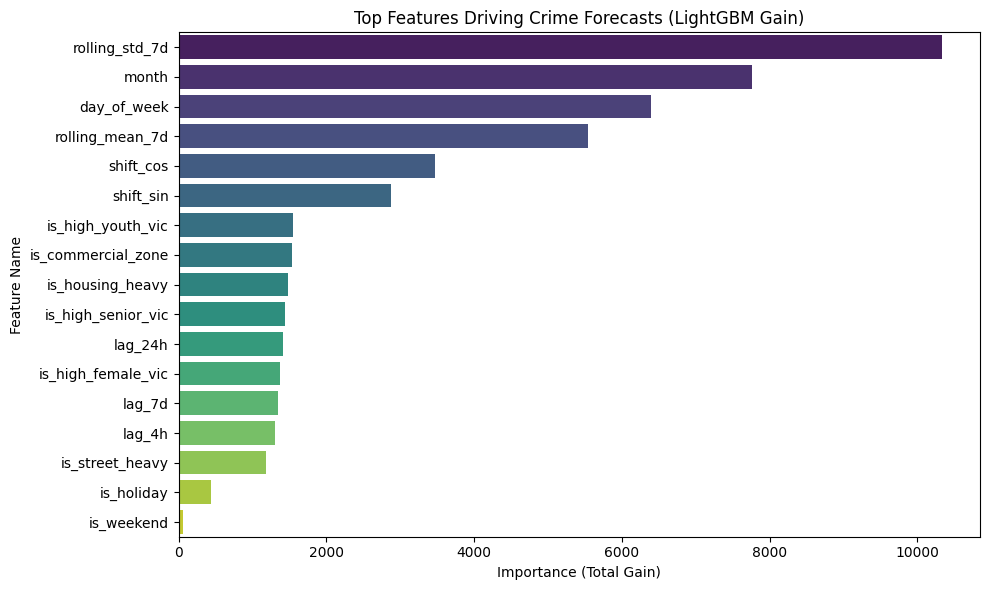

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

#Final fit with the best parameters
best_lgbm.fit(X_train, y_train)

#Get feature importance
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': best_lgbm.feature_importances_
}).sort_values(by='Importance', ascending=False)

#Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top Features Driving Crime Forecasts (LightGBM Gain)')
plt.xlabel('Importance (Total Gain)')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### Final Model Performance Graphs

C:\Users\Nicol\AppData\Local\Temp\ipykernel_19308\2024380112.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model Version', y='MAE', data=performance_comparison, palette='coolwarm')


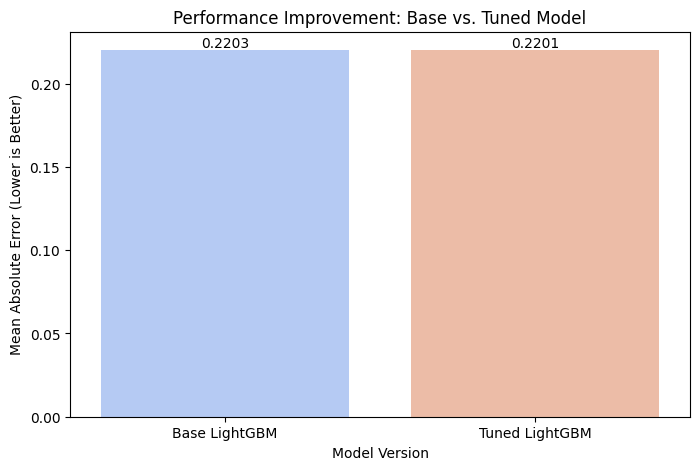

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#comparison data
performance_comparison = pd.DataFrame({
    'Model Version': ['Base LightGBM', 'Tuned LightGBM'],
    'MAE': [lgbm_mae, mean_absolute_error(y_test, best_lgbm.predict(X_test))]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Model Version', y='MAE', data=performance_comparison, palette='coolwarm')
plt.title('Performance Improvement: Base vs. Tuned Model')
plt.ylabel('Mean Absolute Error (Lower is Better)')

for index, row in performance_comparison.iterrows():
    plt.text(index, row.MAE, f'{row.MAE:.4f}', color='black', ha="center", va="bottom")

plt.show()

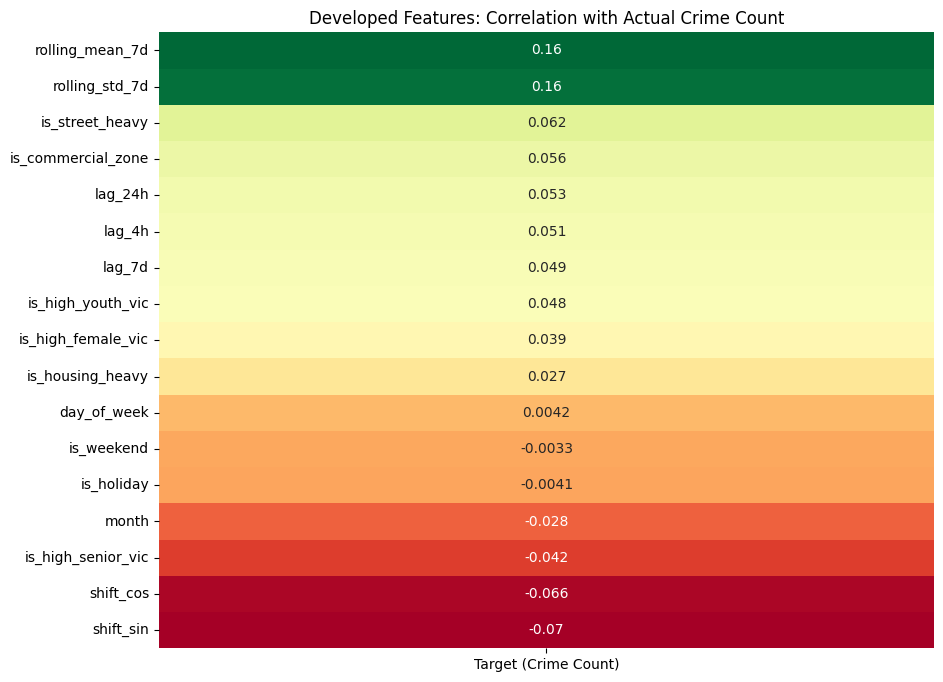

In [27]:
#Compute correlation of features with target
corr_data = X_test.copy()
corr_data['Target (Crime Count)'] = y_test.values
correlations = corr_data.corr()['Target (Crime Count)'].sort_values(ascending=False).drop('Target (Crime Count)')

plt.figure(figsize=(10, 8))
sns.heatmap(correlations.to_frame(), annot=True, cmap='RdYlGn', cbar=False)
plt.title('Developed Features: Correlation with Actual Crime Count')
plt.show()

## Sensitivity Analysis

Baseline MAE (All Features): 0.2201


C:\Users\Nicol\AppData\Local\Temp\ipykernel_19308\2507181448.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAE Increase', y='Feature Removed', data=loo_df, palette='Reds_r')


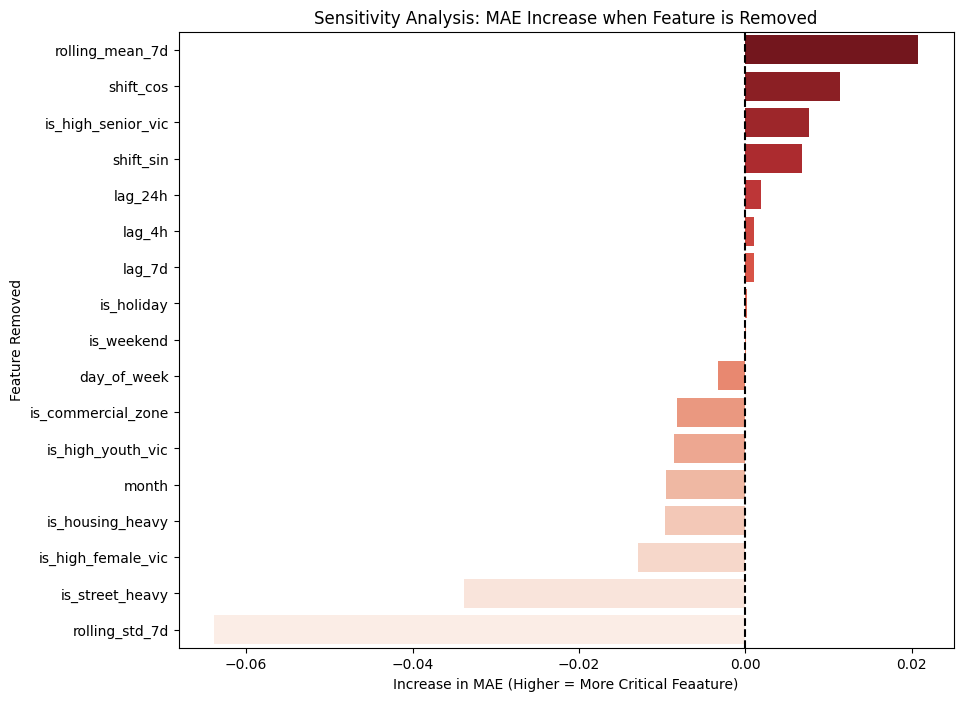

CRITICAL DRIVER: Removing 'rolling_mean_7d' increased error by 9.45%.


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

#MAE with all features intact (baseline)
baseline_preds = best_lgbm.predict(X_test)
baseline_mae = mean_absolute_error(y_test, baseline_preds)
print(f"Baseline MAE (All Features): {baseline_mae:.4f}")

loo_results = []

#leave one-out analysis for each feature
for feature in features:
    X_test_loo = X_test.copy()
    X_test_loo[feature] = 0 
    
    #predict with the feature removed and calculate MAE
    loo_preds = best_lgbm.predict(X_test_loo)
    current_mae = mean_absolute_error(y_test, loo_preds)
    
    #determine how much the MAE increased compared to the baseline
    mae_increase = current_mae - baseline_mae
    
    loo_results.append({
        'Feature Removed': feature,
        'MAE Increase': mae_increase
    })

#visualize the results of the leave-one-out analysis
loo_df = pd.DataFrame(loo_results).sort_values(by='MAE Increase', ascending=False)
loo_df['Percent Increase'] = (loo_df['MAE Increase'] / baseline_mae) * 100

plt.figure(figsize=(10, 8))
sns.barplot(x='MAE Increase', y='Feature Removed', data=loo_df, palette='Reds_r')
plt.axvline(0, color='black', linestyle='--')
plt.title('Sensitivity Analysis: MAE Increase when Feature is Removed')
plt.xlabel('Increase in MAE (Higher = More Critical Feaature)')
plt.show()

#summarize findings
most_critical = loo_df.iloc[0]['Feature Removed']
least_critical = loo_df.iloc[-1]['Feature Removed']

print(f"CRITICAL DRIVER: Removing '{most_critical}' increased error by {loo_df.iloc[0]['Percent Increase']:.2f}%.")

## Optimization Model Export
This is intended to serve as the crime incidents parameter data for the patrol scheduling optimization model

In [ ]:
import os
import pandas as pd
import numpy as np

#Build the grid of all date/shift/precinct combinations for the test period
test_dates = pd.to_datetime(test_df['date'].unique())
all_shifts = [0, 4, 8, 12, 16, 20]

all_prec = sorted(bk_df['ADDR_PCT_CD'].unique())

grid = pd.DataFrame(
    [(d, s, p) for d in test_dates for s in all_shifts for p in all_prec],
    columns=['date', 'shift_window', 'ADDR_PCT_CD']
)
grid['date'] = pd.to_datetime(grid['date'])

#Feature engineering on the grid (same as training data)
grid['shift_sin'] = np.sin(2 * np.pi * grid['shift_window'] / 24)
grid['shift_cos'] = np.cos(2 * np.pi * grid['shift_window'] / 24)
grid['month'] = grid['date'].dt.month
grid['day_of_week'] = grid['date'].dt.dayofweek
grid['is_weekend'] = grid['day_of_week'].isin([5, 6]).astype(int)
holiday_set = set(us_holidays.keys())
grid['is_holiday'] = grid['date'].dt.date.isin(holiday_set).astype(int)

#Attach spatial features from precinct profile
spatial_cols = [
    'is_street_heavy', 'is_housing_heavy', 'is_commercial_zone',
    'is_high_youth_vic', 'is_high_senior_vic', 'is_high_female_vic'
]
grid = grid.merge(
    precinct_profile[spatial_cols].reset_index(),
    on='ADDR_PCT_CD', how='left'
).fillna(0)

#Lag proxy: use per-precinct mean from training data
lag_proxy = (
    ml_data[ml_data['date'].isin(pd.to_datetime(train_df['date'].unique()))]
    .groupby('ADDR_PCT_CD')[['lag_4h', 'lag_24h', 'lag_7d', 'rolling_mean_7d', 'rolling_std_7d']]
    .mean()
    .reset_index()
)
grid = grid.merge(lag_proxy, on='ADDR_PCT_CD', how='left').fillna(0)

#Predict incident count for every cell
X_grid = grid[features]
grid['predicted_incidents'] = best_lgbm.predict(X_grid).clip(min=0)

#Flag high-risk windows
threshold = grid['predicted_incidents'].quantile(0.75) #Top 25% of predicted incident counts are flagged as high-risk
grid['high_risk'] = (grid['predicted_incidents'] >= threshold).astype(int)

shift_labels = {
    0:  '00:00–04:00', 4:  '04:00–08:00', 8:  '08:00–12:00',
    12: '12:00–16:00', 16: '16:00–20:00', 20: '20:00–24:00'
}
grid['shift_label'] = grid['shift_window'].map(shift_labels)

#Export CSV
os.makedirs('opti_inputs', exist_ok=True)
export_cols = ['date', 'shift_window', 'shift_label', 'ADDR_PCT_CD', 'predicted_incidents', 'high_risk']

output_csv = 'crime_predictions.csv'
grid[export_cols].to_csv(output_csv, index=False)
print(f"CSV saved: {output_csv}  ({len(grid)} rows)")

#Summary of the export for quick review
print(f"\n Export Summary")
print(f"Total precinct/shift combos : {len(grid)}")
print(f"High-risk windows flagged   : {grid['high_risk'].sum()}")
print(f"Risk threshold (incidents)  : {threshold:.2f}")
print(f"Brooklyn precincts covered  : {grid['ADDR_PCT_CD'].nunique()}")
print(f"Date range                  : {grid['date'].min().date()} → {grid['date'].max().date()}")
print(f"\nSample high-risk rows:")
print(grid[export_cols][grid['high_risk']==1].head(8).to_string(index=False))

CSV saved: crime_predictions.csv  (22776 rows)

 Export Summary
Total precinct/shift combos : 22776
High-risk windows flagged   : 5694
Risk threshold (incidents)  : 0.17
Brooklyn precincts covered  : 26
Date range                  : 2018-08-09 → 2019-01-01

Sample high-risk rows:
      date  shift_window shift_label  ADDR_PCT_CD  predicted_incidents  high_risk
2018-08-09             0 00:00–04:00           75             0.290186          1
2018-08-09             4 04:00–08:00           75             0.170678          1
2018-08-09             8 08:00–12:00           60             0.174507          1
2018-08-09             8 08:00–12:00           66             0.204136          1
2018-08-09             8 08:00–12:00           67             0.183083          1
2018-08-09             8 08:00–12:00           69             0.181750          1
2018-08-09             8 08:00–12:00           75             0.302211          1
2018-08-09             8 08:00–12:00           90             0